# **Airline Customer Satisfaction Prediction**

## **Introduction**

In the aviation sector, maintaining passenger loyalty requires a rigorous, data-driven approach to measuring and maximizing customer satisfaction. Rather than relying on sporadic, qualitative reviews, modern airlines utilize extensive cross-sectional feedback surveys to capture the exact pain points of travelers across every stage of their journey—from digital pre-flight booking through on-board services to landing delays.

This project builds a predictive machine learning pipeline to classify passenger satisfaction and mathematically isolate the key operational touchpoints of customer sentiment. By utilizing a Binomial Logistic Regression model, we map the log-odds of passenger satisfaction against demographic profiles and 0–5 Likert-scale touchpoints, equipping decision-makers with a precise roadmap for resource allocation.

🔗 Explore the GitHub repo here: [GitHub Repository](https://github.com/Chinaice07/Airline-Customer-Satisfaction-Prediction)


## Overview
**To achieve the objectives of this project, I will:**

* Load the dataset and inspect the target variable (`satisfaction`)
* Encode categorical predictors into a format suitable for Scikit-learn
* Split data into training and testing sets for unbiased model evaluation
* Build a binomial Logistic Regression model to predict probability of "Satisfied"
* Generate a Confusion Matrix and calculate Precision and Recall (not just Accuracy)
* Interpret model coefficients to identify key drivers of satisfaction
* Formulate business recommendations for how the airline can act on model insights


## **Dataset Structure**  
### **Marketing Sales Dataset**  
The dataset used is `Invistico_Airline.csv`, which contains historical survey data from **129,880 passengers** across **22 distinct features**.

#### **Dataset Features Include:**
- **Target Variable (`satisfaction`):** Classified as either 'satisfied' or 'dissatisfied'.
- **Passenger Profiles:** `Customer Type` (Loyal vs. Disloyal), `Age`, `Type of Travel` (Business vs. Personal), and cabin `Class` (Business, Eco, Eco Plus).
- **Core Core Metrics:** `Flight Distance`, `Departure Delay`, and `Arrival Delay`.
- **In-flight & Service Ratings (0-5):** `Seat comfort`, `Inflight entertainment`, `Inflight wifi service`, `Ease of Online booking`, `Online support`, `Cleanliness`, etc.


## **Import Necessary Libraries**

In [1]:
# for data handling, manipulation, and analysis
import pandas as pd

# for data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# for mathematiccal computations
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

## **Data Preparation**

##### a. Data Ingestion and Cleaning

In [2]:
# load dataset using pandas
df = pd.read_csv('/Invistico_Airline.csv')

In [3]:
# check dataset size
df.shape

(129880, 22)

In [4]:
# Inspect the first few rows and the target variable
display(df.head())
print(df['satisfaction'].value_counts(normalize=True))

,satisfaction,Customer Type,Age,Type of Travel,Class,Flight Distance,Seat comfort,Departure/Arrival time convenient,Food and drink,Gate location,...,Online support,Ease of Online booking,On-board service,Leg room service,Baggage handling,Checkin service,Cleanliness,Online boarding,Departure Delay in Minutes,Arrival Delay in Minutes
0,satisfied,Loyal Customer,65,Personal Travel,Eco,265,0,0,0,2,...,2,3,3,0,3,5,3,2,0,0.0
1,satisfied,Loyal Customer,47,Personal Travel,Business,2464,0,0,0,3,...,2,3,4,4,4,2,3,2,310,305.0
2,satisfied,Loyal Customer,15,Personal Travel,Eco,2138,0,0,0,3,...,2,2,3,3,4,4,4,2,0,0.0
3,satisfied,Loyal Customer,60,Personal Travel,Eco,623,0,0,0,3,...,3,1,1,0,1,4,1,3,0,0.0
4,satisfied,Loyal Customer,70,Personal Travel,Eco,354,0,0,0,3,...,4,2,2,0,2,4,2,5,0,0.0


satisfaction
satisfied       0.547328
dissatisfied    0.452672
Name: proportion, dtype: float64


In [5]:
# check for missing values in the dataset
df.isnull().sum()

,0
satisfaction,0
Customer Type,0
Age,0
Type of Travel,0
Class,0
Flight Distance,0
Seat comfort,0
Departure/Arrival time convenient,0
Food and drink,0
Gate location,0


In [6]:
# view rows with NaNs in the 'Arrival Delay in Minutes' column to ascertain if they need to be dropped

df[df['Arrival Delay in Minutes'].isna()]

,satisfaction,Customer Type,Age,Type of Travel,Class,Flight Distance,Seat comfort,Departure/Arrival time convenient,Food and drink,Gate location,...,Online support,Ease of Online booking,On-board service,Leg room service,Baggage handling,Checkin service,Cleanliness,Online boarding,Departure Delay in Minutes,Arrival Delay in Minutes
145,satisfied,Loyal Customer,21,Personal Travel,Eco,4804,0,2,0,4,...,5,5,4,1,4,2,3,5,20,NaN
246,satisfied,Loyal Customer,28,Personal Travel,Eco,1364,0,3,0,4,...,4,2,1,1,3,4,3,2,0,NaN
710,satisfied,Loyal Customer,28,Personal Travel,Eco,1792,0,5,0,3,...,5,5,4,4,5,3,4,5,24,NaN
736,satisfied,Loyal Customer,9,Personal Travel,Eco,1862,0,5,0,4,...,3,3,5,3,4,4,4,3,0,NaN
818,dissatisfied,Loyal Customer,9,Personal Travel,Eco,1668,1,0,1,1,...,4,4,4,5,1,5,1,4,0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
127739,satisfied,Loyal Customer,44,Business travel,Business,3431,2,2,3,2,...,4,5,5,5,5,5,5,4,70,NaN
128131,satisfied,Loyal Customer,39,Business travel,Business,1595,4,4,4,4,...,5,5,5,5,5,3,5,5,0,NaN
128710,satisfied,Loyal Customer,45,Business travel,Eco,871,5,1,1,1,...,2,5,5,5,5,1,5,5,100,NaN
129774,satisfied,disloyal Customer,49,Personal Travel,Eco,1594,5,4,5,2,...,3,3,1,4,3,3,4,3,0,NaN


> The `'Arrival Delay in Minutes'` rows with NaN will not be dropped because there are  other survey data (Seat comfort, Food and drink, Cleanliness, etc.) that are intact. Dropping these 393 rows means losing all those other valid passenger responses.
>
> By inspection the `'Departure Delay in Minutes'` column correlates with the `'Arrival Delay in Minutes'`. We check their correlation to verify their relationship.

In [7]:
correlation = df.corr(numeric_only=True)['Arrival Delay in Minutes'].sort_values(ascending=False)
print(correlation)

Arrival Delay in Minutes             1.000000
Departure Delay in Minutes           0.965291
Flight Distance                      0.110103
Gate location                        0.003640
Departure/Arrival time convenient    0.002599
Leg room service                     0.000472
Age                                 -0.011248
Baggage handling                    -0.014164
Food and drink                      -0.014881
Online boarding                     -0.021784
Checkin service                     -0.023860
Seat comfort                        -0.025506
Inflight entertainment              -0.033321
Inflight wifi service               -0.035270
Online support                      -0.036087
Ease of Online booking              -0.039806
On-board service                    -0.041456
Cleanliness                         -0.067208
Name: Arrival Delay in Minutes, dtype: float64


>A correlation score of 0.9653 is exceptionally high. This statistically proves that departure delay and arrival delay move together almost perfectly.

>Since a plane's arrival delay is heavily correlated with its departure delay, dropping the 'Arrival Delay in Minutes' column is the best approach so as to prevent multicollinearity.

In [8]:
# Drop the 'Arrival Delay in Minutes' column entirely
df = df.drop('Arrival Delay in Minutes', axis=1)

In [9]:
df.columns

Index(['satisfaction', 'Customer Type', 'Age', 'Type of Travel', 'Class',
       'Flight Distance', 'Seat comfort', 'Departure/Arrival time convenient',
       'Food and drink', 'Gate location', 'Inflight wifi service',
       'Inflight entertainment', 'Online support', 'Ease of Online booking',
       'On-board service', 'Leg room service', 'Baggage handling',
       'Checkin service', 'Cleanliness', 'Online boarding',
       'Departure Delay in Minutes'],
      dtype='object')

In [10]:
# check to confirm no NaNs remain
df.isnull().sum()

,0
satisfaction,0
Customer Type,0
Age,0
Type of Travel,0
Class,0
Flight Distance,0
Seat comfort,0
Departure/Arrival time convenient,0
Food and drink,0
Gate location,0


##### b. Feature/Data Encoding
> Since tools (such as `scikit-learn`) to be used later can only parse numerical data, we need to encode (or map) non-numerical data.

In [11]:
# first, let's check the unique values in the 'satisfaction' column
print(df['satisfaction'].unique())

['satisfied' 'dissatisfied']


In [12]:
# Encode the target variable: 'satisfied' = 1, 'dissatisfied' = 0
df['satisfaction'] = df['satisfaction'].map({'satisfied': 1, 'dissatisfied': 0})

# One-hot encode the remaining categorical predictors
df_encoded = pd.get_dummies(df, drop_first=True, dtype=int)

# Separate features (X) and target (y)
X = df_encoded.drop('satisfaction', axis=1)
y = df_encoded['satisfaction']

In [13]:
df_encoded.head(5)

,satisfaction,Age,Flight Distance,Seat comfort,Departure/Arrival time convenient,Food and drink,Gate location,Inflight wifi service,Inflight entertainment,Online support,...,Leg room service,Baggage handling,Checkin service,Cleanliness,Online boarding,Departure Delay in Minutes,Customer Type_disloyal Customer,Type of Travel_Personal Travel,Class_Eco,Class_Eco Plus
0,1,65,265,0,0,0,2,2,4,2,...,0,3,5,3,2,0,0,1,1,0
1,1,47,2464,0,0,0,3,0,2,2,...,4,4,2,3,2,310,0,1,0,0
2,1,15,2138,0,0,0,3,2,0,2,...,3,4,4,4,2,0,0,1,1,0
3,1,60,623,0,0,0,3,3,4,3,...,0,1,4,1,3,0,0,1,1,0
4,1,70,354,0,0,0,3,4,3,4,...,0,2,4,2,5,0,0,1,1,0


##### c. Spliting and Scalling Train/Test data

>Splitting the data ensures unbiased evaluation. Scaling the features is highly recommended for Logistic Regression because it helps the model converge faster and makes the coefficients easier to compare.

In [14]:
# Split the data (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [15]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((103904, 21), (25976, 21), (103904,), (25976,))

> By including `stratify=y`, we guaranteed that the proportion of satisfied to dissatisfied passengers is exactly the same in both the training set and testing set. This prevents the model from getting an unfair distribution of data, ensuring the evaluation metrics (like accuracy or F1-score) are completely reliable.

In [16]:
# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

>`scaler.fit_transform(X_train)` calculates the true mean and variance of the training data only and applies the scaling formula.
>
> `scaler.transform(X_test)` scales the test data using the exact same mean and variance calculated from the training data. This prevents data leakage (giving the model accidental hints about the test set before it makes a prediction).

## **Build and Train the Logistic Regression Model**

>Now we fit the binomial logistic regression model to predict the probability of a passenger being "Satisfied."

In [17]:
# Initialize and train the model
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_scaled, y_train)
log_reg.score(X_train_scaled, y_train)

0.8290248691099477

In [18]:
# Predict on the test set
y_pred = log_reg.predict(X_test_scaled)
y_pred

array([1, 1, 0, ..., 0, 0, 0])

## Model Evaluation

### **a. Precision, Recall and F1-Score**

In [19]:
# Print Precision, Recall, and F1-Score
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.81      0.81      0.81     11759
           1       0.84      0.84      0.84     14217

    accuracy                           0.83     25976
   macro avg       0.83      0.83      0.83     25976
weighted avg       0.83      0.83      0.83     25976



#### **Analytical Findings and Interpretation**
From the report above the following can be deduced:
1. **Support:**

    This is the actual number of passenger records in the test set. There are a total of `25,976` passengersof which `11,759` are **dissatisfied** passengers (Class 0) and `14,217` are **satisfied** passengers (Class 1).

    > *Takeaway*: Because these numbers are relatively close, your dataset is balanced. We do not need to worry about class imbalance distortions.

2. **Precision** (Quality of Predictions):
    
    When the model predicts a passenger belongs to this class, how often is it right?
    > *Class 0 (`0.81`)*: When your model flags a passenger as **dissatisfied**, it is correct `81%` of the time. (`19%` are false alarms).
    >
    > *Class 1 (`0.84`)*: When your model flags a passenger as **satisfied**, it is correct 84% of the time.

3. **Recall** (Completeness of Capture):

    Out of all the actual people in this class, how many did the model manage to find?
    >*Class 0 (`0.81`)*: The model successfully found 81% of all the truly **dissatisfied** customers in the dataset. It missed 19% of them.
    >
    >*Class 1 (`0.84`)*: The model successfully found 84% of all the truly **satisfied** customers.

4. **F1-Score** (The Balance):

    This is the harmonic mathematical blend of Precision and Recall. A high F1-score proves the model isn't sacrificing precision to get high recall, or vice versa.
    >Our values of `0.81` for **dissatisfied**, 0.84 for **satisfied** are above `0.80` thus indicate a highly robust, well-performing classification model.

5. **Averages** (Macro vs. Weighted):
    >*Accuracy (`0.83`)*: The model guessed correctly 83 times out of every 100 passengers.
    >
    >*Macro Avg (`0.83`)*: The raw mathematical average of the classes: \((0.81 + 0.84) / 2 = 0.825\) (rounded to `0.83`).
    >
    >*Weighted Avg (`0.83`)*: The average adjusted for the size of each class.
    
   *Because the dataset is evenly supported, the macro and weighted averages are identical.*

### **b. Confusion Matrix**

>The confusion matrix visually maps out your 25,976 test predictions, showing exactly where your model guessed right and where it made mistakes.

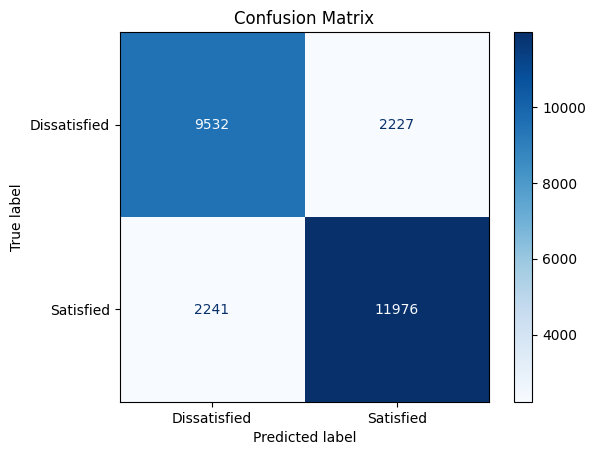

In [20]:
# Generate and plot the Confusion Matrix
cm = confusion_matrix(y_test, y_pred, labels=log_reg.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Dissatisfied', 'Satisfied'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.show()

> *The diagonal blocks (top-left and bottom-right) represent correct predictions, while the other two blocks represent errors.*

#### **Analytical Findings and Interpretation**
The Plot shows four Quadrants. These Quadrant are:
1. True Negatives (Top-Left: `9,532`)
      
      >*Meaning*: `9,532` passengers were actually **dissatisfied**, and the model correctly flagged them as **dissatisfied**.
2. True Positives (Bottom-Right: `11,976`)

      >*Meaning*: `11,976` passengers were actually **satisfied**, and the model correctly flagged them as **satisfied**.
3. False Positives (Top-Right: `2,227`)

      >*Meaning*: `2,227` passengers were actually **dissatisfied**, but the model mistakenly predicted they were **satisfied**.
      >
      >**These are customers slipping through the cracks who might switch airlines without you noticing.**
4. False Negatives (Bottom-Left: `2,241`)

      > Meaning: `2,241` passengers were actually **satisfied**, but the model mistakenly predicted they were **dissatisfied**.
      >
      >**These are false alarms where you might waste marketing resources trying to win back already happy customers.**



## Interpret Coefficients for Business Insights

In [24]:
# Extract feature names and coefficients
feature_names = X.columns
coefficients = log_reg.coef_[0]

# Create a DataFrame for easy viewing
coef_df = pd.DataFrame({'Feature': feature_names, 'Coefficient': coefficients})
coef_df['Absolute_Importance'] = coef_df['Coefficient'].abs()

# Sort by absolute importance to find the key drivers
coef_df = coef_df.sort_values(by='Absolute_Importance', ascending=False)
coef_df

,Feature,Coefficient,Absolute_Importance
7,Inflight entertainment,0.973153,0.973153
17,Customer Type_disloyal Customer,-0.724269,0.724269
2,Seat comfort,0.391161,0.391161
10,On-board service,0.388045,0.388045
13,Checkin service,0.354719,0.354719
19,Class_Eco,-0.354351,0.354351
18,Type of Travel_Personal Travel,-0.349967,0.349967
9,Ease of Online booking,0.331707,0.331707
3,Departure/Arrival time convenient,-0.326360,0.326360
11,Leg room service,0.309148,0.309148


### **Analytical Findings and Interpretation**
1. **Inflight Entertainment** \(`+0.9731`)
    >*Interpretation*: This is this is the key driver of satisfaction. For every 1-point increase a passenger awards inflight entertainment, their odds of being **satisfied** skyrocket.
    >
    > *Actionable Insight*: Invest heavily in modern screens, a diverse movie selection, and reliable headphone jacks. It is the single highest-leverage operational item you have.

2. **Customer Type_disloyal Customer** \(`-0.7242`)
    >*Interpretation*: This is measured against the dropped baseline category, Loyal Customers. Disloyal passengers (e.g., one-off discount shoppers) are aggressively more likely to report being **dissatisfied**, even if the flight experience is identical to a loyal flyer's.
    >
    >*Actionable Insight*: Focus heavily on converting first-time flyers into your loyalty program during or right after the flight. Loyalty creates a psychological buffer against minor flight inconveniences.

3. Seat Comfort (`+0.3911`) & On-Board Service (`+0.3880`)    

    >*Interpretation*: These two variables share nearly identical positive weights. Cabin comfort and attentive flight attendants act as twin structural pillars for satisfying a flyer.

4. Check-in Service (`+0.3547`) & Ease of Online Booking (`+0.3317`)
    >*Interpretation*: Digital convenience matters before the flight even begins. Smooth booking and stress-free check-in lines set a positive tone that protects the rest of the customer journey.

5. Class_Eco (`-0.3543`) vs. Class_Eco Plus (`-0.1980`)
    >*Interpretation*: Both are measured against the dropped baseline category, Business Class. Flying Economy drops satisfaction significantly (`-0.3543`). Flying Economy Plus also drops satisfaction compared to Business, but only by half as much (`-0.1980`).
    >
    >*Actionable Insight*: Upgrading Economy passengers to Economy Plus yields a measurable statistical lift in satisfaction, even if they can't be placed all the way up in Business Class.
6. Type of Travel_Personal Travel (`-0.3499`)

    >*Interpretation*: Measured against Business Travel. Leisure flyers paying out of their own pockets are structurally much harder to satisfy than business travelers whose companies are footing the bill.

5. Departure/Arrival Time Convenient (`-0.3263`)
    >*Interpretation*: This has a surprising negative value. It indicates that passengers forced onto awkward, inconvenient flight schedules (like a 4:00 AM departure) are heavily predisposed to low satisfaction scores overall.
6. Food and Drink (`-0.2952`)
    >*Interpretation*: A negative coefficient here often implies a "hygiene factor." Passengers rarely give a flight 5 stars just because the snacks were decent, but terrible food or empty drink carts actively drive resentment.
7. Departure Delay in Minutes (`-0.1779`)
  >*Interpretation*: Every minute a plane sits idling at the gate actively chips away at customer goodwill.



##**Model Limitations**

While our Logistic Regression model is highly performant, it operates under several structural limitations that must be acknowledged:

1. **Assumption of Linearity in Log-Odds:** Logistic Regression assumes a monotonic, linear relationship between the continuous predictors and the log-odds of the target variable. It cannot automatically capture non-linear behaviors or complex multi-feature interactions (e.g., if older passengers care more about legroom on long-distance flights vs. short-distance flights) without manual interaction feature engineering.

2. **Remaining Multicollinearity Risk:** Although we successfully mitigated extreme multicollinearity by dropping `Arrival Delay in Minutes` (which had a 0.9653 correlation with departure delay), minor multicollinearity may still exist among multi-point satisfaction surveys (e.g., passengers who rate 'Cleanliness' highly are highly likely to rate 'Seat Comfort' highly as well), which can slightly distort individual coefficient weights.

3. **Subjective Scale Variance:** The dataset relies heavily on 0-5 subjective customer ratings. The boundary between a score of '3' and '4' is highly non-uniform and varies based on individual passenger psychology and expectations.

4. **Cross-Sectional Constraints:** The survey data acts as a snapshot in time. It lacks seasonal contexts (such as holiday travel surges vs. business off-seasons) or macroeconomic indicators that dynamically alter passenger patience levels and overall sentiment.

## **Final Thoughts**
The Logistic Regression model confirms that **Inflight Entertainment (+0.973)** and **Ease of Online Booking (+0.331)** are highly influential positive drivers of passenger satisfaction. Conversely, traveling for **Personal Travel (-0.350)** or flying in **Eco Class (-0.354)** are strong structural baselines for customer friction. These insights provide the airline with clear, quantifiable operational targets to optimize capital allocation and maximize retention.

## **Strategic Recommendations**
To maximize airline satisfaction with minimal waste:
1. Optimize Inflight Entertainment (highest ROI).
2. Create standard operational loops to cross-sell loyalty status to Disloyal Customers.
3. Target Economy Plus upgrades specifically to personal leisure travelers, as they are your highest-risk segments for dissatisfaction.
